# **Import Libraries and Data**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Retail AI Solution/Datasets/Recommendation/Content Based/handm.csv')

In [ ]:
df.head(2)

,Unnamed: 0,productId,productName,brandName,url,price,stockState,comingSoon,colorName,isOnline,colors,colorShades,newArrival,mainCatCode,details,materials
0,0,834333001,Derby Shoes,H&M,https://www2.hm.com/en_us/productpage.0834333001.html,49.99,Available,False,Black,True,272628,Charcoal,False,men_shoes_dressed,"Derby shoes with open lacing at front. Canvas lining and insoles. Heel height 1 in.\nArt. No.:0834333001\nHeel Height:\nLow heel\nFootwear type:\nDerby Shoes\nDescription:\nBlack, Solid-color\nImported:\nYes","COMPOSITION\nSole:Thermoplastic rubber 100%\nUpper:Polyurethane 100%\nLining and insole:Cotton 100% , ADDITIONAL MATERIAL INFORMATION\nThe total weight of this product contains:\n37% Recycled thermoplastic rubber\n1% Recycled cotton\nWe exclude the weight of minor components such as, but not exclusively: threads, buttons, zippers, embellishments and prints.\nThe total weight of the product is calculated by adding the weight of all layers and main components together. Based on that, we calculate how much of that weight is made out by each material. For sets and multipacks, all pieces are counted together as one product in calculations. , We exclude the weight of minor components such as, but not exclusively: threads, buttons, zippers, embellishments and prints.\nThe total weight of the product is calculated by adding the weight of all layers and main components together. Based on that, we calculate how much of that weight is made out by each material. For sets and multipacks, all pieces are counted together as one product in calculations. , Material:\nCanvas , MATERIALS IN THIS PRODUCT EXPLAINED\nCotton\nCotton is a soft and versatile natural fiber harvested from the cotton plant.\nPolyurethane\nPolyurethane (PU) is a synthetic material made from oil (a fossil resource).\nRecycled cotton\nRecycled cotton is cotton made from textile waste in production or from end-of-life textile waste. The waste is mechanically recycled and spun into new yarn.\nRecycled thermoplastic rubber\nRecycled thermoplastic rubber (TPR) is a synthetic rubber made from a type of polymer (a fossil resource). It has the characteristics of both rubber and plastic. Recycled TPR is made from plastic waste.\nThermoplastic rubber\nThermoplastic rubber (TPR) is a synthetic rubber made from a type of polymer (a fossil resource). It has the characteristics of both rubber and plastic. , Cotton\nCotton is a soft and versatile natural fiber harvested from the cotton plant. , Polyurethane\nPolyurethane (PU) is a synthetic material made from oil (a fossil resource). , Recycled cotton\nRecycled cotton is cotton made from textile waste in production or from end-of-life textile waste. The waste is mechanically recycled and spun into new yarn. , Recycled thermoplastic rubber\nRecycled thermoplastic rubber (TPR) is a synthetic rubber made from a type of polymer (a fossil resource). It has the characteristics of both rubber and plastic. Recycled TPR is made from plastic waste. , Thermoplastic rubber\nThermoplastic rubber (TPR) is a synthetic rubber made from a type of polymer (a fossil resource). It has the characteristics of both rubber and plastic."
1,1,1258600003,Pile-Lined Slippers,H&M,https://www2.hm.com/en_us/productpage.1258600003.html,24.99,Available,False,Black,True,272628,Charcoal,False,men_shoes_slippers,"Slippers in napped fabric. Decorative seam at top, fluted soles, and lining in soft pile. Sole thickness 3/4 in.\nArt. No.:1258600003\nHeel Height:\nNo heel\nDescription:\nBlack, Solid-color\nImported:\nYes","COMPOSITION\nLining:Polyester 100%\nUpper:Polyurethane 100%\nSole:Ethylene Vinyl Acetate 100% , ADDITIONAL MATERIAL INFORMATION\nThe total weight of this product contains:\n26% Recycled polyester\n11% Recycled ethylene-vinyl acetate\nWe exclude the weight of minor components such as, but not exclusively: threads, buttons, zippers, embellishments and prints.\nThe total weight of the product is calculated by adding the weight of all layers and main

In [ ]:
df.shape

(9677, 16)

In [ ]:
df.columns

Index(['Unnamed: 0', 'productId', 'productName', 'brandName', 'url', 'price',
       'stockState', 'comingSoon', 'colorName', 'isOnline', 'colors',
       'colorShades', 'newArrival', 'mainCatCode', 'details', 'materials'],
      dtype='object')

In [ ]:
# Check for duplicates in the 'productid' column
df['productId'].duplicated().sum()

np.int64(2006)

In [ ]:
new_df = df.drop_duplicates(subset='productId', keep='first')
new_df['productId'].duplicated().sum()

np.int64(0)

In [ ]:
new_df.reset_index(drop=True, inplace=True)

In [ ]:
new_df.columns

Index(['Unnamed: 0', 'productId', 'productName', 'brandName', 'url', 'price',
       'stockState', 'comingSoon', 'colorName', 'isOnline', 'colors',
       'colorShades', 'newArrival', 'mainCatCode', 'details', 'materials'],
      dtype='object')

In [ ]:
# Product Name, Color, Materials

new_df = new_df[['productName', 'brandName', 'url', 'price', 'stockState', 'comingSoon', 'isOnline', 'newArrival', 'colorName', 'materials']]
new_df.head(3)

,productName,brandName,url,price,stockState,comingSoon,isOnline,newArrival,colorName,materials
0,Derby Shoes,H&M,https://www2.hm.com/en_us/productpage.0834333001.html,49.99,Available,False,True,False,Black,"COMPOSITION\nSole:Thermoplastic rubber 100%\nUpper:Polyurethane 100%\nLining and insole:Cotton 100% , ADDITIONAL MATERIAL INFORMATION\nThe total weight of this product contains:\n37% Recycled thermoplastic rubber\n1% Recycled cotton\nWe exclude the weight of minor components such as, but not exclusively: threads, buttons, zippers, embellishments and prints.\nThe total weight of the product is calculated by adding the weight of all layers and main components together. Based on that, we calculate how much of that weight is made out by each material. For sets and multipacks, all pieces are counted together as one product in calculations. , We exclude the weight of minor components such as, but not exclusively: threads, buttons, zippers, embellishments and prints.\nThe total weight of the product is calculated by adding the weight of all layers and main components together. Based on that, we calculate how much of that weight is made out by each material. For sets and multipacks, all pieces are counted together as one product in calculations. , Material:\nCanvas , MATERIALS IN THIS PRODUCT EXPLAINED\nCotton\nCotton is a soft and versatile natural fiber harvested from the cotton plant.\nPolyurethane\nPolyurethane (PU) is a synthetic material made from oil (a fossil resource).\nRecycled cotton\nRecycled cotton is cotton made from textile waste in production or from end-of-life textile waste. The waste is mechanically recycled and spun into new yarn.\nRecycled thermoplastic rubber\nRecycled thermoplastic rubber (TPR) is a synthetic rubber made from a type of polymer (a fossil resource). It has the characteristics of both rubber and plastic. Recycled TPR is made from plastic waste.\nThermoplastic rubber\nThermoplastic rubber (TPR) is a synthetic rubber made from a type of polymer (a fossil resource). It has the characteristics of both rubber and plastic. , Cotton\nCotton is a soft and versatile natural fiber harvested from the cotton plant. , Polyurethane\nPolyurethane (PU) is a synthetic material made from oil (a fossil resource). , Recycled cotton\nRecycled cotton is cotton made from textile waste in production or from end-of-life textile waste. The waste is mechanically recycled and spun into new yarn. , Recycled thermoplastic rubber\nRecycled thermoplastic rubber (TPR) is a synthetic rubber made from a type of polymer (a fossil resource). It has the characteristics of both rubber and plastic. Recycled TPR is made from plastic waste. , Thermoplastic rubber\nThermoplastic rubber (TPR) is a synthetic rubber made from a type of polymer (a fossil resource). It has the characteristics of both rubber and plastic."
1,Pile-Lined Slippers,H&M,https://www2.hm.com/en_us/productpage.1258600003.html,24.99,Available,False,True,False,Black,"COMPOSITION\nLining:Polyester 100%\nUpper:Polyurethane 100%\nSole:Ethylene Vinyl Acetate 100% , ADDITIONAL MATERIAL INFORMATION\nThe total weight of this product contains:\n26% Recycled polyester\n11% Recycled ethylene-vinyl acetate\nWe exclude the weight of minor components such as, but not exclusively: threads, buttons, zippers, embellishments and prints.\nThe total weight of the product is calculated by adding the weight of all layers and main components together. Based on that, we calculate how much of that weight is made out by each material. For sets and multipacks, all pieces are counted together as one product in calculations. , We exclude the weight of minor components such as, but not exclusively: threads, buttons, zippers, embellishments and prints.\nThe total weight of the product is calculated by adding the weight of all layers and main components together. Based on that, we calculate how much of that weight is made out by each material. For sets and multipacks, all pieces are counted together a

In [ ]:
new_df.isnull().sum()

,0
productName,0
brandName,0
url,0
price,0
stockState,0
comingSoon,0
isOnline,0
newArrival,0
colorName,0
materials,122


In [ ]:
new_df = new_df[new_df['materials'].notna()].copy()
new_df.isnull().sum()

,0
productName,0
brandName,0
url,0
price,0
stockState,0
comingSoon,0
isOnline,0
newArrival,0
colorName,0
materials,0


In [ ]:
new_df.shape

(7549, 10)

In [ ]:
new_df.reset_index(drop=True, inplace=True)

In [ ]:
new_df.shape

(7549, 10)

In [ ]:
print(new_df['materials'][0])

COMPOSITION
Sole:Thermoplastic rubber 100%
Upper:Polyurethane 100%
Lining and insole:Cotton 100% , ADDITIONAL MATERIAL INFORMATION
The total weight of this product contains:
37% Recycled thermoplastic rubber
1% Recycled cotton
We exclude the weight of minor components such as, but not exclusively: threads, buttons, zippers, embellishments and prints.
The total weight of the product is calculated by adding the weight of all layers and main components together. Based on that, we calculate how much of that weight is made out by each material. For sets and multipacks, all pieces are counted together as one product in calculations. , We exclude the weight of minor components such as, but not exclusively: threads, buttons, zippers, embellishments and prints.
The total weight of the product is calculated by adding the weight of all layers and main components together. Based on that, we calculate how much of that weight is made out by each material. For sets and multipacks, all pieces are coun

In [ ]:
# Clean the materials texts
def clean_text(text):
  text = text.lower()
  # Extract material names and percentages (e.g., "cotton 100%", "recycled thermoplastic rubber 37%")
  material_pattern = r'(\w+(?:\s+\w+)*)\s*:\s*([\w\s]+)\s+(\d+%|\d+\.\d+%)(?=\s|$|,|\n)'
  material_matches = re.findall(material_pattern, text)

  # Extract standalone material names (e.g., "Canvas")
  standalone_material_pattern = r'material:\s*(\w+(?:\s+\w+)*)(?=\s|$|,|\n)'
  standalone_materials = re.findall(standalone_material_pattern, text)

  # Combine materials with percentages and standalone materials
  materials = []
  for match in material_matches:
    # match[0] is the component (e.g., "Sole", "Upper"), match[1] is the material, match[2] is the percentage
    materials.append(f"{match[1]} {match[2]}".strip())
  materials.extend(standalone_materials)  # Add standalone materials like "Canvas"

  # Join materials into a single string
  cleaned_text = ' '.join(materials)

  # Further clean the text
  cleaned_text = re.sub(r'[^\w\s%]', '', cleaned_text)  # Remove punctuation except %
  cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()  # Remove extra spaces
  return cleaned_text

new_df['materials'] = new_df['materials'].apply(clean_text)
print(new_df['materials'][0])

thermoplastic rubber 100% polyurethane 100% cotton 100% canvas


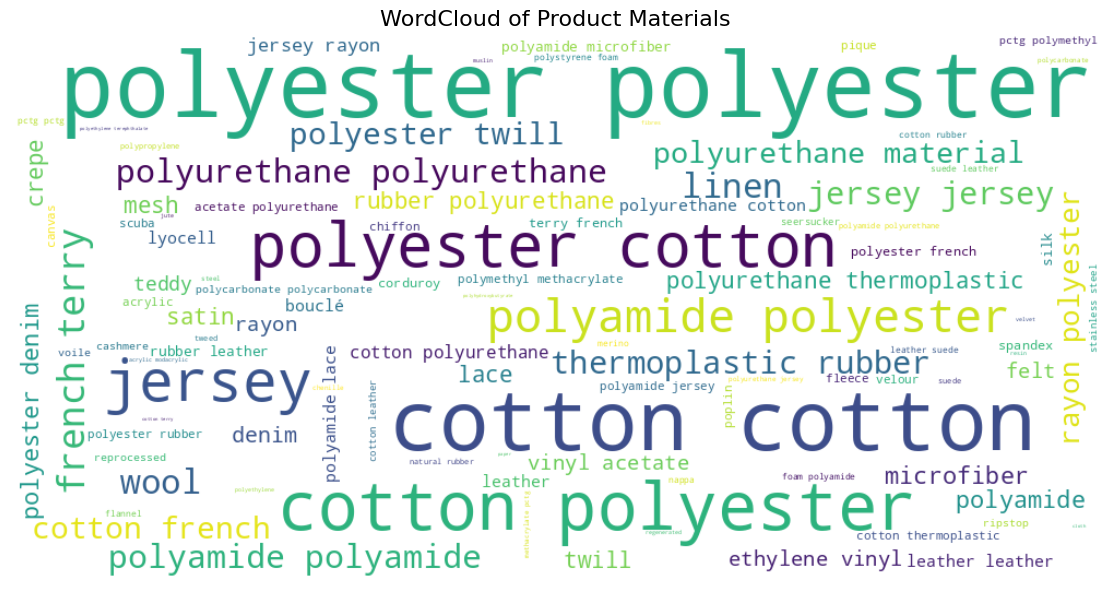

In [ ]:
all_words = ' '.join(new_df['materials']).split()
wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(' '.join(all_words))
plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud of Product Materials', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# new_df["productName"] = new_df["productName"].apply(lambda x: x.replace(" ", ""))
# new_df["colorName"] = new_df["colorName"].apply(lambda x: x.replace(" ", ""))
# new_df["materials"] = new_df["materials"].apply(lambda x: x.replace(" ", ""))

In [ ]:
new_df.head(2)

,productName,brandName,url,price,stockState,comingSoon,isOnline,newArrival,colorName,materials
0,Derby Shoes,H&M,https://www2.hm.com/en_us/productpage.0834333001.html,49.99,Available,False,True,False,Black,thermoplastic rubber 100% polyurethane 100% cotton 100% canvas
1,Pile-Lined Slippers,H&M,https://www2.hm.com/en_us/productpage.1258600003.html,24.99,Available,False,True,False,Black,polyester 100% polyurethane 100% ethylene vinyl acetate 100% polyurethane material


In [ ]:
new_df.columns

Index(['productName', 'brandName', 'url', 'price', 'stockState', 'comingSoon',
       'isOnline', 'newArrival', 'colorName', 'materials'],
      dtype='object')

In [ ]:
new_df['color'] = new_df['colorName']

In [ ]:
# Combine attributes into a space-separated tags column
new_df['tags'] =  new_df['colorName'].str.lower() + ' ' + new_df['colorName'].str.lower() + ' ' + new_df['materials'].str.lower()

# Now drop the original columns
new_df = new_df.drop(columns=['colorName', 'materials'])

# View first few rows to check
new_df.head()

,productName,brandName,url,price,stockState,comingSoon,isOnline,newArrival,color,tags
0,Derby Shoes,H&M,https://www2.hm.com/en_us/productpage.0834333001.html,49.99,Available,False,True,False,Black,black black thermoplastic rubber 100% polyurethane 100% cotton 100% canvas
1,Pile-Lined Slippers,H&M,https://www2.hm.com/en_us/productpage.1258600003.html,24.99,Available,False,True,False,Black,black black polyester 100% polyurethane 100% ethylene vinyl acetate 100% polyurethane material
2,Derby Shoes,H&M,https://www2.hm.com/en_us/productpage.1036812001.html,56.99,Available,False,True,False,Black,black black cotton 100% polyester 100% thermoplastic rubber 100% canvas
3,Fleece-lined Slippers,H&M,https://www2.hm.com/en_us/productpage.1112924002.html,29.99,Available,False,True,False,Dark blue,dark blue dark blue polyester 100% polyester 100% ethylene vinyl acetate 100%
4,Sneakers,H&M,https://www2.hm.com/en_us/productpage.1119476020.html,29.99,Available,False,True,False,White,white white polyester 100% polyurethane 100% rubber 100% polyurethane material


In [ ]:
new_df["tags"][0]

'black black thermoplastic rubber 100% polyurethane 100% cotton 100% canvas'

In [ ]:
# Clean tags
new_df['tags'] = new_df['tags'].str.split().str.join(' ')

# Calculate the length of each entry in the 'tags' column
tag_lengths = new_df['tags'].str.len()

# Compute the minimum, mean, median, and maximum lengths
min_length = tag_lengths.min()
mean_length = tag_lengths.mean()
median_length = tag_lengths.median()
max_length = tag_lengths.max()

# Print the results
print(f"Minimum length of tags: {min_length}")
print(f"Mean length of tags: {mean_length:.2f}")
print(f"Median length of tags: {median_length}")
print(f"Maximum length of tags: {max_length}")

Minimum length of tags: 7
Mean length of tags: 37.90
Median length of tags: 37.0
Maximum length of tags: 156


In [ ]:
new_df.tail()

,productName,brandName,url,price,stockState,comingSoon,isOnline,newArrival,color,tags
7544,Slim Straight High Jeans,H&M,https://www2.hm.com/en_us/productpage.1199187014.html,34.99,Available,False,True,False,Beige,beige beige cotton 99% polyester 65% denim
7545,Bootcut High Jeans,H&M,https://www2.hm.com/en_us/productpage.1198343002.html,39.99,Available,False,True,False,Light denim blue,light denim blue light denim blue cotton 99% polyester 65% cotton
7546,Lace Push-up Bra,H&M,https://www2.hm.com/en_us/productpage.1232588003.html,17.99,Available,False,True,False,Powder pink,powder pink powder pink polyamide 88% polyester 100% polyamide 83% lace
7547,2-pack Padded Soft-cup Cotton Bras,H&M,https://www2.hm.com/en_us/productpage.1208310002.html,24.99,Available,False,True,False,Beige/black,beige/black beige/black cotton 95% polyester 100% jersey
7548,Padded Balconette Bikini Top,H&M,https://www2.hm.com/en_us/productpage.1227825002.html,19.99,Available,False,True,False,Brown,brown brown polyester 93% polyester 89% polyamide 100%


# **Model Building**

In [ ]:
# Vectorization using TF-IDF
tfidf = TfidfVectorizer(max_features=300, stop_words='english')
vectors = tfidf.fit_transform(new_df['tags']).toarray()

In [ ]:
# Create a pseudo-label for supervised learning
# Use productName as a proxy for clustering similar items
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(new_df['productName'])

In [ ]:
# Train a Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(vectors, labels)

RandomForestClassifier(random_state=42)

In [ ]:
# Train a KNN model
knn_model = NearestNeighbors(n_neighbors=10, metric='cosine', algorithm='brute')
knn_model.fit(vectors)

NearestNeighbors(algorithm='brute', metric='cosine', n_neighbors=10)

In [ ]:
# Calculate cosine similarity for TF-IDF vectors
similarity = cosine_similarity(vectors)

In [ ]:
similarity[0]

array([1.        , 0.43450424, 0.93943829, ..., 0.05820171, 0.28134702,
       0.08284846])

In [ ]:
new_df.columns

Index(['productName', 'brandName', 'url', 'price', 'stockState', 'comingSoon',
       'isOnline', 'newArrival', 'color', 'tags'],
      dtype='object')

In [ ]:
# Recommendation function using Random Forest, KNN, and Cosine Similarity
def recommend(cloth):
  try:
    # Normalize input and product names for case-insensitive and whitespace-robust matching
    cloth = cloth.strip().lower()
    product_names = new_df['productName'].str.strip().str.lower()

    # Find matching product
    matching_indices = new_df[product_names == cloth].index
    if len(matching_indices) == 0:
      print(f"Product '{cloth}' not found in the dataset.")
      print("Available product names (first 10):")
      print(new_df['productName'].head(10).tolist())
      return

    cloth_index = matching_indices[0]

    # Verify index is within bounds
    if cloth_index >= len(new_df):
      print(f"Error: cloth_index {cloth_index} is out of bounds for new_df with size {len(new_df)}")
      return

    # Get cosine similarity scores
    distances = similarity[cloth_index]

    # Get Random Forest predictions
    cloth_vector = vectors[cloth_index].reshape(1, -1)
    rf_probs = rf_model.predict_proba(cloth_vector)[0]

    # Get KNN neighbors
    knn_distances, knn_indices = knn_model.kneighbors(cloth_vector, n_neighbors=min(10, len(new_df)))
    knn_scores = 1 - knn_distances[0]  # Convert distances to similarity scores

    # Ensure knn_indices are valid
    valid_knn_indices = knn_indices[0][knn_indices[0] < len(new_df)]
    if len(valid_knn_indices) == 0:
      print("No valid KNN indices found.")
      return

    # Initialize combined_scores array
    combined_scores = np.zeros(len(new_df))
    combined_scores += 0.5 * distances

    # Map Random Forest probabilities to DataFrame rows
    rf_indices = label_encoder.transform(new_df['productName'])
    rf_contribution = np.zeros(len(new_df))
    for idx, label_idx in enumerate(rf_indices):
      if label_idx < len(rf_probs):
        rf_contribution[idx] = rf_probs[label_idx]
    combined_scores += 0.2 * rf_contribution

    # Add KNN scores for valid indices
    knn_contribution = np.zeros(len(new_df))
    for i, idx in enumerate(valid_knn_indices):
      if i < len(knn_scores):
        knn_contribution[idx] = knn_scores[i]
    combined_scores += 0.3 * knn_contribution

    # Get top 10 candidates to filter later
    cloth_list = sorted(list(enumerate(combined_scores)), reverse=True, key=lambda x: x[1])[1:10]

    # Filter out recommendations with the same product name
    recommended = []
    for i in cloth_list:
      if i[0] < len(new_df) and new_df.iloc[i[0]]['productName'].strip().lower() != cloth:
        recommended.append(i)
      if len(recommended) >= 5:  # Stop when we have 5 valid recommendations
        break

    # Print recommendations
    if not recommended:
      print("No recommendations found with different product names.")
      return

    for i in recommended:
      print(f"Product: {new_df.iloc[i[0]]['productName']}")
      print(f"Brand: {new_df.iloc[i[0]]['brandName']}")
      print(f"Color: {new_df.iloc[i[0]]['color']}")
      print(f"Price: {new_df.iloc[i[0]]['price']}")
      print(f"Availability: {new_df.iloc[i[0]]['stockState']}")
      print(f"Online Availability: {new_df.iloc[i[0]]['isOnline']}")
      print(f"New Product: {new_df.iloc[i[0]]['newArrival']}")
      print(f"Link: {new_df.iloc[i[0]]['url']}")
      print(f"Similarity Score: {i[1]:.4f}")
      print("\n")

  except Exception as e:
    print(f"An error occurred: {str(e)}")
    return

In [ ]:
print(new_df['productName'][0:5])

0              Derby Shoes
1      Pile-Lined Slippers
2              Derby Shoes
3    Fleece-lined Slippers
4                 Sneakers
Name: productName, dtype: object


In [ ]:
recommend('Derby Shoes')

Product: Canvas Toiletry Bag
Brand: H&M
Color: Black
Price: 19.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1113325001.html
Similarity Score: 0.6951


Product: Canvas Espadrilles
Brand: H&M
Color: Black
Price: 26.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1215175001.html
Similarity Score: 0.6894


Product: Loafers
Brand: H&M
Color: Black
Price: 54.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1178834007.html
Similarity Score: 0.6769


Product: Loafers
Brand: H&M
Color: Black
Price: 54.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1178834002.html
Similarity Score: 0.6769


Product: Loafers
Brand: H&M
Color: Black
Price: 34.99
Availability: Available
Online Availability: True
New Product: False
Link: https://

In [ ]:
recommend('Pile-Lined Slippers')

Product: Chunky Derby Shoes
Brand: H&M
Color: Black
Price: 64.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1072732001.html
Similarity Score: 0.7889


Product: Chunky Platform Sandals
Brand: H&M
Color: Black
Price: 39.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1224749002.html
Similarity Score: 0.7605


Product: Sandals
Brand: H&M
Color: Black
Price: 34.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1223178001.html
Similarity Score: 0.7555


Product: Lace-Up Boots
Brand: H&M
Color: Black
Price: 74.99
Availability: Available
Online Availability: True
New Product: True
Link: https://www2.hm.com/en_us/productpage.1250009001.html
Similarity Score: 0.7424


Product: Chelsea Boots
Brand: H&M
Color: Black
Price: 59.99
Availability: Available
Online Availability: True
New Product: False

In [ ]:
recommend('Teddy Fleece Slippers')

Product: Warm-lined Slippers
Brand: H&M
Color: Dark brown
Price: 19.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1003418010.html
Similarity Score: 0.7640


Product: Warm-lined Boots
Brand: H&M
Color: Dark brown
Price: 24.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1172015003.html
Similarity Score: 0.7553


Product: Intertwined-strap Sandals
Brand: H&M
Color: Dark brown
Price: 29.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1224746003.html
Similarity Score: 0.7334


Product: Warm-lined Slippers
Brand: H&M
Color: Brown
Price: 19.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1003418006.html
Similarity Score: 0.7140


Product: Chunky Derby Shoes
Brand: H&M
Color: Dark brown
Price: 54.99
Availability: Available


In [ ]:
recommend('Chunky Derby Shoesi')

Product 'chunky derby shoesi' not found in the dataset.
Available product names (first 10):
['Derby Shoes', 'Pile-Lined Slippers', 'Derby Shoes', 'Fleece-lined Slippers', 'Sneakers', 'Sneakers', 'Chelsea Boots', 'Chelsea Boots', 'Loafers', 'Chelsea Boots']


In [ ]:
recommend('Chunky Derby Shoes')

Product: Chelsea Boots
Brand: H&M
Color: Black
Price: 59.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1250116001.html
Similarity Score: 0.7924


Product: Lace-Up Boots
Brand: H&M
Color: Black
Price: 74.99
Availability: Available
Online Availability: True
New Product: True
Link: https://www2.hm.com/en_us/productpage.1250009001.html
Similarity Score: 0.7854


Product: Chunky Platform Sandals
Brand: H&M
Color: Black
Price: 39.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1224749002.html
Similarity Score: 0.7727


Product: Sandals
Brand: H&M
Color: Black
Price: 34.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1223178001.html
Similarity Score: 0.7683


Product: Trekking Boots
Brand: H&M
Color: Black
Price: 91.99
Availability: Available
Online Availability: True
New Product: False
Lin

In [ ]:
recommend('Sneakers')

Product: Faux Leather Sneakers
Brand: H&M
Color: White
Price: 36.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1002745005.html
Similarity Score: 0.8525


Product: Small Crossbody Bag
Brand: H&M
Color: White
Price: 17.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1238251006.html
Similarity Score: 0.7478


Product: Shoulder Bag
Brand: H&M
Color: White
Price: 19.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1188402004.html
Similarity Score: 0.7229




In [ ]:
recommend('Walking Boots')

Product: Sneakers
Brand: H&M
Color: Beige
Price: 34.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1238773002.html
Similarity Score: 0.8885


Product: Fluffy Slippers
Brand: H&M
Color: Beige
Price: 24.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1249147002.html
Similarity Score: 0.7455


Product: Warm-lined Boots
Brand: H&M
Color: Beige
Price: 59.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1193143005.html
Similarity Score: 0.7386


Product: Chunky Chelsea Boots
Brand: H&M
Color: Beige
Price: 49.99
Availability: Available
Online Availability: True
New Product: False
Link: https://www2.hm.com/en_us/productpage.1239744002.html
Similarity Score: 0.7362


Product: Laced Padded Boots
Brand: H&M
Color: Beige
Price: 59.99
Availability: Available
Online Availability: True
New Product: F

In [ ]:
recommend('Green Embroidered and Printed Handloom Viscose Ethnic Scarf')

Product 'green embroidered and printed handloom viscose ethnic scarf' not found in the dataset.
Available product names (first 10):
['Derby Shoes', 'Pile-Lined Slippers', 'Derby Shoes', 'Fleece-lined Slippers', 'Sneakers', 'Sneakers', 'Chelsea Boots', 'Chelsea Boots', 'Loafers', 'Chelsea Boots']


# **Evaluation**

In [ ]:
# Function to check if two items are relevant based on shared color or materials
def is_relevant(item1_tags, item2_tags, item1_color, item2_color):
  item1_materials = set(item1_tags.split())
  item2_materials = set(item2_tags.split())
  return item1_color == item2_color or len(item1_materials.intersection(item2_materials)) > 0

In [ ]:
# Modified recommendation function to return indices and scores for evaluation
def get_recommendations(cloth, df, vectors, similarity, rf_model, knn_model, label_encoder, K=5):
  try:
    cloth = cloth.strip().lower()
    product_names = df['productName'].str.strip().str.lower()
    matching_indices = df[product_names == cloth].index
    if len(matching_indices) == 0:
      return []

    cloth_index = matching_indices[0]
    if cloth_index >= len(df):
      return []

    # Get cosine similarity scores
    distances = similarity[cloth_index]

    # Get Random Forest predictions
    cloth_vector = vectors[cloth_index].reshape(1, -1)
    rf_probs = rf_model.predict_proba(cloth_vector)[0]

    # Get KNN neighbors
    knn_distances, knn_indices = knn_model.kneighbors(cloth_vector, n_neighbors=min(10, len(df)))
    knn_scores = 1 - knn_distances[0]

    # Initialize combined_scores
    combined_scores = np.zeros(len(df))
    combined_scores += 0.2 * distances

    # Map Random Forest probabilities
    rf_indices = label_encoder.transform(df['productName'])
    rf_contribution = np.zeros(len(df))
    for idx, label_idx in enumerate(rf_indices):
      if label_idx < len(rf_probs):
        rf_contribution[idx] = rf_probs[label_idx]
    combined_scores += 0.3 * rf_contribution

    # Add KNN scores
    knn_contribution = np.zeros(len(df))
    for i, idx in enumerate(knn_indices[0]):
      if i < len(knn_scores) and idx < len(df):
        knn_contribution[idx] = knn_scores[i]
    combined_scores += 0.5 * knn_contribution

    # Get top candidates
    cloth_list = sorted(list(enumerate(combined_scores)), reverse=True, key=lambda x: x[1])[1:10]

    # Filter out same product name
    recommended = []
    for i in cloth_list:
      if i[0] < len(df) and df.iloc[i[0]]['productName'].strip().lower() != cloth:
        recommended.append(i)
      if len(recommended) >= K:
        break
    return recommended
  except Exception:
    return []

In [ ]:
# Function to compute Precision@K for a single product
def precision_at_k(cloth, df, vectors, similarity, rf_model, knn_model, label_encoder, K=5):
  recommended = get_recommendations(cloth, df, vectors, similarity, rf_model, knn_model, label_encoder, K)
  if not recommended:
    return 0.0

  input_product = df[df['productName'].str.strip().str.lower() == cloth.strip().lower()].iloc[0]
  input_tags = input_product['tags']
  input_color = input_product['color']

  relevant_count = 0
  for idx, _ in recommended:
    if idx < len(df):
      rec_product = df.iloc[idx]
      rec_tags = rec_product['tags']
      rec_color = rec_product['color']
      if is_relevant(input_tags, rec_tags, input_color, rec_color):
        relevant_count += 1

  return relevant_count / K

In [ ]:
# Evaluate Precision@K across a sample of products
def evaluate_model(df, vectors, similarity, rf_model, knn_model, label_encoder, sample_size=100, K=5):
  sample_indices = np.random.choice(df.index, size=min(sample_size, len(df)), replace=False)
  precisions = []
  for idx in sample_indices:
    cloth = df.iloc[idx]['productName']
    precision = precision_at_k(cloth, df, vectors, similarity, rf_model, knn_model, label_encoder, K)
    precisions.append(precision)

  avg_precision = np.mean(precisions)
  return avg_precision

In [ ]:
# Run evaluation
sample_size = new_df.shape[0]
K = 10
avg_precision = evaluate_model(new_df, vectors, similarity, rf_model, knn_model, label_encoder, sample_size, K)
print(f"Average Precision@{K}: {avg_precision:.4f}")

Average Precision@10: 0.8181
